# Computer Exercise 15.34 — Problem 3
## 시간의 축 — 시간 평균을 고정하고 탐색 잡음의 **방향**만 뒤집는다

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 Ch 15
> **단원**: §15.34 Sequential Decision Making — When, Not How Much
> **선행**: §15.33 P3 (Day 100) · §15.34 P2 (오늘)
> **풀이 일자**: Day 101 · **언어**: Python (NumPy / pandas / Matplotlib / SciPy)

Day 100 P3 의 참고 비교 `cnrt_mc − cnrt = +0.1020` ($p = 0.0008$) 은 하나의 가설을 남겼다:

> "자유 학습의 문제는 배분이 아니라 **초기 구간의 잡음이 작다**는 것이다."

그 문장에는 아직 실험이 없다. `cnrt_mc` 는 처음부터 끝까지 크고 `cnrt` 는 처음에만 작으므로,
두 arm 은 **크기**와 **타이밍**이 교락되어 있다. 오늘 그것을 분리한다 —
$\sigma$ 의 **시간 평균을 고정**한 채 시간 프로파일만 바꾼다.

핵심은 감쇠 스케줄과 증가 스케줄이 **시간 평균과 시간 rms 를 동시에 공유**한다는 것이다
(§2.2). 두 arm 은 오직 **시간의 방향**에서만 다르다. 이것은 Day 100 P3 과 오늘 P2 가
씨름한 "한 모멘트만 고정된다" 는 한계가 **구조적으로 없는** 유일한 비교다.

## 1. 문제 (원문)

> **Computer Exercise 15.34.3.** Exercise 15.33.3 observed that constraining the exploration-noise
> scale from the first step recovered most of the loss suffered by a freely-learned scale, and
> conjectured that the operative variable is *when* the noise is large rather than *how* it is
> distributed across coordinates. Design an experiment that separates timing from magnitude.
>
> Hold the *time average* $\langle \sigma \rangle_T = T^{-1}\sum_{t<T} \sigma(t)$ fixed and compare
> a decaying schedule, a constant schedule and a growing schedule. Show that the decaying and
> growing linear schedules share both their time mean *and* their time rms, so that they differ
> only in the direction of time. Pre-register a family of four comparisons, verify the schedules
> by assertion, include an A/A check and a magnitude reference, and report the lure-lock-in rate
> as a mechanism diagnostic. State whether "when" is a real axis or a restatement of "how much".

### 한국어 풀이용 정리

1. **시간 평균 고정** — 세 스케줄 모두 $\langle \sigma \rangle_T = 0.55$ 가 되도록 구성한다.
2. **감쇠 대 증가가 1 차 판정** — 두 스케줄은 시간 평균과 시간 rms 를 **둘 다** 공유하므로,
   차이는 **오직 방향**이다. 다른 어떤 비교보다 깨끗하다.
3. **사전 명시 가족 $m=4$** — $g_1$ (감쇠−일정), $g_2$ (감쇠−증가), $g_3$ (증가−일정),
   $g_4$ (일정−작은 고정; 크기 축척 기준).
4. **2 차** — 계단형 스케줄 (전반 큼 / 후반 큼) 로 결론이 **모양**이 아니라 **방향**에
   달렸는지 확인.
5. **메커니즘 진단** — 미끼 고착률: 최종 탐욕 정책이 상태 0 에서 미끼 쪽으로 가는 시드 비율.

## 2. 수학적 배경

### 2.1 스케줄의 정의

기저 스케일 $\sigma_0 = 0.55$ 에 시간 인자 $c(u)$, $u = t/T \in [0,1)$ 를 곱한다:
$\sigma(t) = \sigma_0\, c(t/T)$. 시간 평균이 $\sigma_0$ 가 되려면 $\int_0^1 c(u)\,du = 1$ 이어야 한다.

$$c_{\text{const}}(u) = 1, \qquad
c_{\text{decay}}(u) = a - b u, \qquad
c_{\text{grow}}(u) = (a-b) + b u, \qquad (a, b) = (1.9,\, 1.8).$$

세 스케줄 모두 $\int_0^1 c = 1$ 이다. 계단형은 $c_{\text{step}\uparrow}(u) = 1.8\cdot\mathbb 1[u<\tfrac12] + 0.2\cdot\mathbb 1[u\ge\tfrac12]$ 와 그 반전.

### 2.2 감쇠와 증가는 두 모멘트를 모두 공유한다

$c_{\text{grow}}(u) = c_{\text{decay}}(1-u)$ 이므로 $u \mapsto 1-u$ 는 $[0,1]$ 의 측도보존 변환이고,
따라서 **$c$ 의 모든 시간 모멘트가 일치**한다. 이산 구현에서도 이것이 **정확히** 성립하려면
격자가 $u \mapsto 1-u$ 에 대해 닫혀 있어야 한다 — 중점 격자 $u_t = (t+\tfrac12)/T$,
$t = 0,\dots,T-1$ 이 그 조건을 만족한다 ($1 - u_t = u_{T-1-t}$):

$$\boxed{\;\int_0^1 c_{\text{grow}}(u)^k\,du \;=\; \int_0^1 c_{\text{decay}}(u)^k\,du \quad \forall k \ge 1.\;}$$

구체적으로 $\int_0^1 c^2 = a^2 - ab + b^2/3 = 3.61 - 3.42 + 1.08 = 1.27$ 이므로 두 스케줄의
시간 rms 는 모두 $\sigma_0\sqrt{1.27} = 1.127\,\sigma_0$ 로 같고, 일정 스케줄의 $\sigma_0$ 보다 크다.

이 사실이 실험 설계에서 갖는 의미는 결정적이다. Day 100 P3 과 오늘 P2 는 **한 모멘트만
고정할 수 있다**는 제약과 싸웠다 (P2 §2.1). $g_2 = R_{\text{decay}} - R_{\text{grow}}$ 에는
그 제약이 **없다** — 두 arm 은 잡음의 주변분포가 완전히 동일하고 오직 시간 순서만 다르다.
따라서

$$g_2 \ne 0 \;\Longrightarrow\; \text{"언제" 는 "얼마나" 로 환원되지 않는다.}$$

는 함의가 어떤 보조 가정도 없이 성립한다. 반대로 $g_1, g_3$ 은 일정 스케줄과의 비교이므로
시간 rms 가 다르고 ($1.127\sigma_0$ 대 $\sigma_0$), 그만큼 해석에 단서가 붙는다.

### 2.3 왜 초기 잡음이 중요할 것으로 예상되는가

이 chain MDP 는 상태 0 에 미끼 보상 $R_{\text{local}} = 0.25$ 를, 상태 4 에 목표 보상 $1.0$ 을 둔다.
학습은 상태 0 에서 시작하므로, 초기에 탐색이 약하면 $Q(0,\text{left})$ 가 먼저 커지고
탐욕 정책이 미끼에 고착한다. 일단 고착하면 TD 목표가 스스로를 강화하므로 **후기의 큰 잡음은
이미 늦다** — 잡음은 정책을 흔들 뿐 $Q$ 의 순서를 되돌리려면 목표 상태에 반복 도달해야 하는데,
고착된 정책 아래에서는 그 방문 자체가 드물다. 예측:

$$R_{\text{decay}} \;>\; R_{\text{const}} \;>\; R_{\text{grow}}, \qquad
\text{미끼 고착률}_{\text{decay}} \;<\; \text{미끼 고착률}_{\text{grow}}.$$

### 2.4 판정 규칙

P1 · P2 와 동일: 부호뒤집기 순열검정 ($B = 20000$), 가족 $m=4$ 에 Holm, 검정 반전 CI,
비유의 셀에 $n^\star$. 비유의는 **판정불능**으로 읽는다.

## 3. 풀이 흐름

1. **공통 설정** — Day 99–101 계열의 chain MDP (미끼 $0.25$), 트렁크 MLP + Factorized Noisy
   헤드, 시간 스케줄 $c(u)$ 를 받는 `train`.
2. **사전 명시** — 가설·가족·규칙·$n$·중지 규칙을 자료 생성 전에 못박는다.
3. **[1] 스케줄 검증** — 시간 격자를 중점 $u_t = (t+\tfrac12)/T$ 로 두면 $u \mapsto 1-u$ 가
   격자를 자기 자신으로 보내므로, 감쇠와 증가가 **이산 격자 위에서도 정확한 거울상**이 된다.
   시간 평균이 $0.55$ 로 일치하고 두 쌍의 시간 rms 가 일치하는지 **수치로 assert**.
4. **[2] 7 개 arm 학습·배포** — `base`, `fix_small`, `const`, `decay`, `grow`,
   `step_early`, `step_late`.
5. **[3] 개입 검증** — 실제 학습 루프에서 소비된 $\sigma$ 의 시간 평균/rms 를 기록해 확인.
6. **[4] A/A 점검**.
7. **[5] 판정** — 1 차 가족 $m=4$ + Holm, 2 차로 계단형과 미끼 고착률.
8. **[6]–[8] 시각화와 요약** — 스케줄 궤적, forest plot, 고착률, 판정표.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL, SIGMA0 = 0.95, 0.05, 16, 0.25, 0.5
SIG_INIT, SIG_T = SIGMA0 / np.sqrt(H), 0.55

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    return s2, (1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0))

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

# ── 시간 스케줄 c(u),  int_0^1 c = 1 ─────────────────────────────────────
A_LIN, B_LIN = 1.9, 1.8
SCHED = {
  "const":      lambda u: np.ones_like(np.asarray(u, float)),
  "decay":      lambda u: A_LIN - B_LIN * np.asarray(u, float),
  "grow":       lambda u: (A_LIN - B_LIN) + B_LIN * np.asarray(u, float),
  "step_early": lambda u: np.where(np.asarray(u, float) < 0.5, 1.8, 0.2),
  "step_late":  lambda u: np.where(np.asarray(u, float) < 0.5, 0.2, 1.8),
}

class Learner:
    def __init__(self, rng, noisy=True, sigma_init=SIG_T):
        self.h = H; self.inject = noisy; self.scale = 1.0
        self.W1 = rng.normal(0, 0.3, (H, NS)); self.b1 = np.zeros(H)
        self.W2 = rng.normal(0, 0.3, (NA, H)); self.b2 = np.zeros(NA)
        self.Ws = np.full((NA, H), sigma_init); self.bs = np.full(NA, sigma_init)
        self.eps_W = np.zeros((NA, H)); self.eps_b = np.zeros(NA)
    def resample(self, rng):
        if not self.inject: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo
    def q(self, s, noise=False):
        a1 = np.tanh(self.W1 @ onehot(s) + self.b1)
        use = noise and self.inject
        W = self.W2 + (self.Ws * self.scale * self.eps_W if use else 0.0)
        b = self.b2 + (self.bs * self.scale * self.eps_b if use else 0.0)
        return W @ a1 + b, a1
    def update(self, s, a, target):
        qv, a1 = self.q(s); d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        gz = (d * self.W2[a]) * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz

def train(seed, T, sched=None, sigma_init=SIG_T, noisy=True, p_train=0.20,
          eps_greedy=0.10, trace_every=None):
    """noisy=True 이면 sigma(t) = sigma_init * c(t/T) 로 잡음 탐색, 아니면 eps-greedy."""
    rng = np.random.default_rng(seed)
    lr = Learner(rng, noisy=noisy, sigma_init=sigma_init)
    c = SCHED[sched] if sched else (lambda u: 1.0)
    lr.trace = []; lr.consumed = []; s = 0
    for t in range(T):
        if t % L == 0: s = 0; lr.resample(rng)
        lr.scale = float(c((t + 0.5) / T))
        lr.consumed.append(sigma_init * lr.scale)
        if lr.inject:
            a = int(np.argmax(lr.q(s, noise=True)[0]))
        else:
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(lr.q(s)[0]))
        s2, r = step(s, a, p_train, rng)
        lr.update(s, a, r + GAMMA * float(np.max(lr.q(s2)[0])))
        s = s2
        if trace_every and t % trace_every == 0:
            lr.trace.append((t, sigma_init * lr.scale))
    lr.consumed = np.array(lr.consumed)
    return lr

def greedy_policy(lr): return tuple(int(np.argmax(lr.q(s)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    rng = np.random.default_rng(seed); pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

T_FIXED, P_DEPLOY, N_EP = 10_000, 0.20, 40
ALPHA, B_MAIN = 0.05, 20_000

def signflip_p(d, B=B_MAIN, seed=1, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    d = np.asarray(d, float); obs = abs(d.mean())
    null = np.abs((rng.choice([-1.0, 1.0], size=(B, len(d))) * d).mean(axis=1))
    return float((1 + (null >= obs - 1e-15).sum()) / (B + 1))

def holm(pv, alpha=ALPHA):
    p = np.asarray(pv, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for k, i in enumerate(order):
        run = max(run, (m - k) * p[i]); adj[i] = min(1.0, run)
    return adj, adj <= alpha

_CI = {}
def invert_ci(d, B=3000, seed=7, alpha=ALPHA, it=22):
    d = np.asarray(d, float); key = (d.tobytes(), B, seed)
    if key in _CI: return _CI[key]
    c = d.mean(); ok = lambda x: signflip_p(d - x, B=B, seed=seed) > alpha
    if not ok(c): _CI[key] = (np.nan, np.nan); return _CI[key]
    a, b = c, c + 2.0
    for _ in range(it):
        m = .5*(a+b); a, b = (m, b) if ok(m) else (a, m)
    up = .5*(a+b); a, b = c - 2.0, c
    for _ in range(it):
        m = .5*(a+b); a, b = (a, m) if ok(m) else (m, b)
    _CI[key] = (.5*(a+b), up); return _CI[key]

def n_star(d, c=2.8):
    d = np.asarray(d, float); m, s = abs(d.mean()), d.std(ddof=1)
    return int(np.ceil((c*s/m)**2)) if m > 1e-12 else np.inf

def wilson(k, n, z=1.96):
    p = k/n; den = 1 + z*z/n; ctr = (p + z*z/(2*n))/den
    hw = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/den
    return (max(0., ctr-hw), min(1., ctr+hw))

print(f"chain MDP  states={NS} 미끼={R_LOCAL} 목표=1.0 · 시작 상태 = 0 (미끼 옆)")
print(f"기저 sigma = {SIG_T} · 스케줄 {list(SCHED)}")
print("판정 규칙: sign-flip + Holm + 검정 반전 CI  [프로토콜 v2]")

chain MDP  states=5 미끼=0.25 목표=1.0 · 시작 상태 = 0 (미끼 옆)
기저 sigma = 0.55 · 스케줄 ['const', 'decay', 'grow', 'step_early', 'step_late']
판정 규칙: sign-flip + Holm + 검정 반전 CI  [프로토콜 v2]


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [사전 명시 — PRE-REGISTRATION]   자료 생성 전에 실행
# ══════════════════════════════════════════════════════════════════════════
PRE = {
 "질문": "탐색 잡음의 시간 프로파일은 크기와 독립적인 축인가",
 "개입": "sigma(t) = 0.55 * c(t/T),  int_0^1 c = 1  (시간 평균 고정)",
 "1차 가족 (m=4, 순서 고정)": [
   "g1 = decay - const     <- 감쇠 대 일정",
   "g2 = decay - grow      <- 방향만 다른 비교 (시간 mean 과 rms 를 둘 다 공유) ★ 핵심",
   "g3 = grow  - const     <- 증가 대 일정",
   "g4 = const - fix_small <- 크기 효과 (축척 기준 = 알려진 큰 효과)",
 ],
 "1차 판정 규칙": "부호뒤집기 순열검정 B=20000, alpha=0.05, Holm(m=4), 검정 반전 CI",
 "표본 크기": "n=40 신규 독립 시드 101401-101440 (Day 100·P1·P2 와 모두 비중첩)",
 "사전 예측": "R(decay) > R(const) > R(grow),  미끼 고착률은 반대 순서 (§2.3)",
 "2차 (보정 없음)": "step_early - step_late (모양이 아니라 방향인지) · 미끼 고착률",
 "필수 점검": "스케줄 시간 모멘트 assert + A/A 점검",
 "중지 규칙": "n=40 을 다 쓰고 한 번만 판정한다.",
}
print("═"*78); print("PRE-REGISTRATION   (Day 101 §15.34 P3)"); print("═"*78)
for k, v in PRE.items():
    if isinstance(v, list): print(f"{k}:"); [print(f"    - {x}") for x in v]
    else: print(f"{k}: {v}")
print("═"*78)
SEEDS3 = list(range(101401, 101441)); N3 = len(SEEDS3)
print(f"판정 풀 n={N3}  (101401-101440)")

══════════════════════════════════════════════════════════════════════════════
PRE-REGISTRATION   (Day 101 §15.34 P3)
══════════════════════════════════════════════════════════════════════════════
질문: 탐색 잡음의 시간 프로파일은 크기와 독립적인 축인가
개입: sigma(t) = 0.55 * c(t/T),  int_0^1 c = 1  (시간 평균 고정)
1차 가족 (m=4, 순서 고정):
    - g1 = decay - const     <- 감쇠 대 일정
    - g2 = decay - grow      <- 방향만 다른 비교 (시간 mean 과 rms 를 둘 다 공유) ★ 핵심
    - g3 = grow  - const     <- 증가 대 일정
    - g4 = const - fix_small <- 크기 효과 (축척 기준 = 알려진 큰 효과)
1차 판정 규칙: 부호뒤집기 순열검정 B=20000, alpha=0.05, Holm(m=4), 검정 반전 CI
표본 크기: n=40 신규 독립 시드 101401-101440 (Day 100·P1·P2 와 모두 비중첩)
사전 예측: R(decay) > R(const) > R(grow),  미끼 고착률은 반대 순서 (§2.3)
2차 (보정 없음): step_early - step_late (모양이 아니라 방향인지) · 미끼 고착률
필수 점검: 스케줄 시간 모멘트 assert + A/A 점검
중지 규칙: n=40 을 다 쓰고 한 번만 판정한다.
══════════════════════════════════════════════════════════════════════════════
판정 풀 n=40  (101401-101440)


In [3]:
# ── [1] 스케줄 검증 (§2.2) — 학습 전에 수식만으로 ────────────────────────
u = (np.arange(T_FIXED) + 0.5) / T_FIXED   # 중점 격자: 0.5 에 대해 정확히 대칭
sch = pd.DataFrame([{"스케줄": k,
                     "시간 평균 c": SCHED[k](u).mean(),
                     "시간 rms c":  np.sqrt((SCHED[k](u)**2).mean()),
                     "sigma 시간평균": SIG_T * SCHED[k](u).mean(),
                     "sigma 시간rms":  SIG_T * np.sqrt((SCHED[k](u)**2).mean())}
                    for k in SCHED])
print(sch.to_string(index=False))
m_dev = np.abs(sch["시간 평균 c"] - 1.0).max()
r_dg  = abs(sch.loc[sch.스케줄=="decay","시간 rms c"].item() -
            sch.loc[sch.스케줄=="grow","시간 rms c"].item())
r_se  = abs(sch.loc[sch.스케줄=="step_early","시간 rms c"].item() -
            sch.loc[sch.스케줄=="step_late","시간 rms c"].item())
assert m_dev < 1e-12, f"시간 평균 불일치 {m_dev:.2e}"
assert r_dg  < 1e-12, f"decay/grow 시간 rms 불일치 {r_dg:.2e}"
assert r_se  < 1e-12, f"step 쌍 시간 rms 불일치 {r_se:.2e}"
print(f"\n✓ 다섯 스케줄 시간 평균이 모두 1 (최대 편차 {m_dev:.2e})")
print(f"✓ decay 와 grow 의 시간 rms 가 일치 (차 {r_dg:.2e})  -> 두 arm 은 오직 방향만 다르다")
print(f"✓ step_early 와 step_late 도 마찬가지 (차 {r_se:.2e})")
print(f"  이론값 int c^2 = a^2 - ab + b^2/3 = "
      f"{A_LIN**2 - A_LIN*B_LIN + B_LIN**2/3:.4f}  (실측 {SCHED['decay'](u).__pow__(2).mean():.4f})")

       스케줄  시간 평균 c  시간 rms c  sigma 시간평균  sigma 시간rms
     const   1.0000    1.0000      0.5500       0.5500
     decay   1.0000    1.1269      0.5500       0.6198
      grow   1.0000    1.1269      0.5500       0.6198
step_early   1.0000    1.2806      0.5500       0.7043
 step_late   1.0000    1.2806      0.5500       0.7043

✓ 다섯 스케줄 시간 평균이 모두 1 (최대 편차 2.22e-16)
✓ decay 와 grow 의 시간 rms 가 일치 (차 0.00e+00)  -> 두 arm 은 오직 방향만 다르다
✓ step_early 와 step_late 도 마찬가지 (차 0.00e+00)
  이론값 int c^2 = a^2 - ab + b^2/3 = 1.2700  (실측 1.2700)


In [4]:
# ── [2] 7 개 arm 학습·배포 ────────────────────────────────────────────────
t0 = time.time(); LS = {}
LS["base"]       = [train(s, T_FIXED, noisy=False) for s in SEEDS3]
LS["fix_small"]  = [train(s, T_FIXED, sched="const", sigma_init=SIG_INIT) for s in SEEDS3]
LS["const"]      = [train(s, T_FIXED, sched="const",      trace_every=250) for s in SEEDS3]
LS["decay"]      = [train(s, T_FIXED, sched="decay",      trace_every=250) for s in SEEDS3]
LS["grow"]       = [train(s, T_FIXED, sched="grow",       trace_every=250) for s in SEEDS3]
LS["step_early"] = [train(s, T_FIXED, sched="step_early", trace_every=250) for s in SEEDS3]
LS["step_late"]  = [train(s, T_FIXED, sched="step_late",  trace_every=250) for s in SEEDS3]
ORDER = ["base", "fix_small", "grow", "step_late", "const", "step_early", "decay"]
R3   = {nm: np.array([deploy(l, P_DEPLOY, N_EP, 840_000 + i) for i, l in enumerate(LS[nm])])
        for nm in ORDER}
POL3 = {nm: [greedy_policy(l) for l in LS[nm]] for nm in ORDER}
LURE = {nm: float(np.mean([p[0] == 0 for p in POL3[nm]])) for nm in ORDER}
print(f"7 arm x {N3} 시드 x T={T_FIXED}  ({time.time()-t0:.1f} s)\n")
print(pd.DataFrame([{"arm": nm, "R_mean": R3[nm].mean(), "R_sd": R3[nm].std(ddof=1),
                     "미끼 고착률": LURE[nm]} for nm in ORDER]).to_string(index=False))

7 arm x 40 시드 x T=10000  (92.3 s)

       arm  R_mean   R_sd  미끼 고착률
      base  0.5364 0.1361  0.1000
 fix_small  0.3562 0.1950  0.5250
      grow  0.5366 0.1135  0.2000
 step_late  0.5474 0.0977  0.2000
     const  0.5761 0.0587  0.0750
step_early  0.5893 0.0213  0.0000
     decay  0.5893 0.0213  0.0000


In [5]:
# ── [3] 개입 검증: 실제 학습 루프가 소비한 sigma ─────────────────────────
con = pd.DataFrame([{"arm": nm,
                     "소비 sigma 시간평균": float(np.mean([l.consumed.mean() for l in LS[nm]])),
                     "소비 sigma 시간rms":  float(np.mean([np.sqrt((l.consumed**2).mean())
                                                           for l in LS[nm]]))}
                    for nm in ["const", "decay", "grow", "step_early", "step_late", "fix_small"]])
print(con.to_string(index=False))
sub = con[con.arm.isin(["const", "decay", "grow", "step_early", "step_late"])]
dev = np.abs(sub["소비 sigma 시간평균"] - SIG_T).max()
dev2 = abs(con.loc[con.arm=="decay","소비 sigma 시간rms"].item() -
           con.loc[con.arm=="grow", "소비 sigma 시간rms"].item())
assert dev  < 1e-12, f"소비 시간평균 이탈 {dev:.2e}"
assert dev2 < 1e-12, f"decay/grow 소비 시간rms 이탈 {dev2:.2e}"
print(f"\n✓ 다섯 스케줄이 실제로 소비한 sigma 의 시간 평균이 {SIG_T} (최대 편차 {dev:.2e})")
print(f"✓ decay 와 grow 의 소비 시간 rms 가 일치 (차 {dev2:.2e})")
print("  -> g2 = decay - grow 에는 어떤 모멘트 교락도 없다. 남은 차이는 시간의 방향뿐이다.")

       arm  소비 sigma 시간평균  소비 sigma 시간rms
     const         0.5500          0.5500
     decay         0.5500          0.6198
      grow         0.5500          0.6198
step_early         0.5500          0.7043
 step_late         0.5500          0.7043
 fix_small         0.1250          0.1250

✓ 다섯 스케줄이 실제로 소비한 sigma 의 시간 평균이 0.55 (최대 편차 1.11e-16)
✓ decay 와 grow 의 소비 시간 rms 가 일치 (차 0.00e+00)
  -> g2 = decay - grow 에는 어떤 모멘트 교락도 없다. 남은 차이는 시간의 방향뿐이다.


In [6]:
# ── [4] A/A 점검 (프로토콜 v2 필수) ──────────────────────────────────────
M_AA, B_AA, N_AA = 500, 2000, 20
rng = np.random.default_rng(2718)
pool = R3["const"] - R3["const"].mean()
rej = sum(signflip_p(rng.choice(pool, N_AA, True) - rng.choice(pool, N_AA, True),
                     B=B_AA, rng=rng) <= ALPHA for _ in range(M_AA))
rate = rej / M_AA; w = wilson(rej, M_AA)
print(f"A/A (재무작위화, M={M_AA}, n={N_AA}) 1종 오류 = {rate:.3f}  "
      f"Wilson 95% CI [{w[0]:.3f}, {w[1]:.3f}]  명목 {ALPHA}")
print("통과 — 규칙이 명목을 지킨다" if w[0] <= ALPHA <= w[1] else "경보 — 명목 이탈")

A/A (재무작위화, M=500, n=20) 1종 오류 = 0.060  Wilson 95% CI [0.042, 0.084]  명목 0.05
통과 — 규칙이 명목을 지킨다


In [7]:
# ── [5] 판정: 1차 가족 (m=4) + 2차 ───────────────────────────────────────
t0 = time.time()
FAM = [("g1  decay - const      (감쇠 대 일정)",       R3["decay"] - R3["const"]),
       ("g2  decay - grow    ★ (방향만 다름)",         R3["decay"] - R3["grow"]),
       ("g3  grow  - const      (증가 대 일정)",       R3["grow"]  - R3["const"]),
       ("g4  const - fix_small  (크기 효과, 축척)",     R3["const"] - R3["fix_small"])]
ps = [signflip_p(d, seed=500+i) for i, (_, d) in enumerate(FAM)]
adj, rej_ = holm(ps)
fam_df = pd.DataFrame([{"비교": nm, "d": d.mean(), "sd": d.std(ddof=1),
                        "CI_low": invert_ci(d)[0], "CI_high": invert_ci(d)[1],
                        "p": p, "p_Holm": pa, "기각": "★" if rj else "", "n*": n_star(d)}
                       for (nm, d), p, pa, rj in zip(FAM, ps, adj, rej_)])
print("1차 가족\n"); print(fam_df.to_string(index=False))

SEC = [("h1  step_early - step_late (계단형: 방향)", R3["step_early"] - R3["step_late"]),
       ("h2  step_early - const",                    R3["step_early"] - R3["const"]),
       ("h3  decay - step_early    (모양)",          R3["decay"] - R3["step_early"]),
       ("h4  const - base          (잡음 대 eps-greedy)", R3["const"] - R3["base"])]
sec_df = pd.DataFrame([{"비교": nm, "d": d.mean(), "p": signflip_p(d, seed=600+i),
                        "n*": n_star(d)} for i, (nm, d) in enumerate(SEC)])
print("\n2차 — Holm 보정 없음\n"); print(sec_df.to_string(index=False))

lure_df = pd.DataFrame([{"arm": nm, "미끼 고착률": LURE[nm],
                         "Wilson_low": wilson(int(LURE[nm]*N3), N3)[0],
                         "Wilson_high": wilson(int(LURE[nm]*N3), N3)[1],
                         "R_mean": R3[nm].mean()} for nm in ORDER])
print("\n메커니즘 진단 — 미끼 고착률 (최종 탐욕 정책이 상태 0 에서 왼쪽)\n")
print(lure_df.to_string(index=False))
r_lu = np.corrcoef([LURE[n] for n in ORDER], [R3[n].mean() for n in ORDER])[0, 1]
print(f"\n고착률과 배포 수익의 상관 r = {r_lu:+.3f}   ({time.time()-t0:.1f} s)")

1차 가족

                                비교       d     sd  CI_low  CI_high      p  p_Holm 기각  n*
  g1  decay - const      (감쇠 대 일정)  0.0132 0.0558  0.0000   0.0293 0.2472  0.2472    141
    g2  decay - grow    ★ (방향만 다름)  0.0527 0.1137  0.0176   0.0873 0.0088  0.0264  ★  37
  g3  grow  - const      (증가 대 일정) -0.0395 0.1012 -0.0710  -0.0084 0.0109  0.0264  ★  52
g4  const - fix_small  (크기 효과, 축척)  0.2199 0.1838  0.1610   0.2790 0.0000  0.0002  ★   6

2차 — Holm 보정 없음

                                         비교      d      p       n*
       h1  step_early - step_late (계단형: 방향) 0.0419 0.0082  43.0000
                     h2  step_early - const 0.0132 0.2476 141.0000
             h3  decay - step_early    (모양) 0.0000 1.0000      inf
h4  const - base          (잡음 대 eps-greedy) 0.0397 0.1086 111.0000

메커니즘 진단 — 미끼 고착률 (최종 탐욕 정책이 상태 0 에서 왼쪽)

       arm  미끼 고착률  Wilson_low  Wilson_high  R_mean
      base  0.1000      0.0396       0.2305  0.5364
 fix_small  0.5250      0.3750       0.6706  0.35

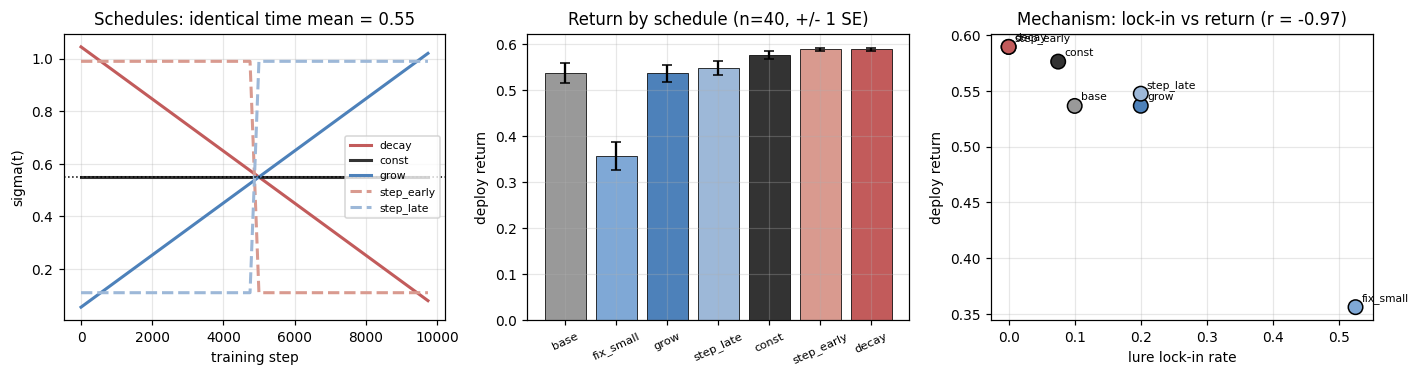

In [8]:
# ── [6] Fig 1 — 스케줄 궤적과 수익 ───────────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
col = {"base": "#999", "fix_small": "#7fa8d6", "grow": "#4d81ba", "step_late": "#9db8d8",
       "const": "#333", "step_early": "#d99a8f", "decay": "#c25b5b"}
for nm in ["decay", "const", "grow", "step_early", "step_late"]:
    tr = np.array(LS[nm][0].trace)
    ax[0].plot(tr[:, 0], tr[:, 1], color=col[nm], lw=2,
               ls="--" if nm.startswith("step") else "-", label=nm)
ax[0].axhline(SIG_T, color="k", ls=":", lw=1)
ax[0].set_xlabel("training step"); ax[0].set_ylabel("sigma(t)")
ax[0].set_title("Schedules: identical time mean = 0.55"); ax[0].legend(fontsize=7)

x = np.arange(len(ORDER))
ax[1].bar(x, [R3[n].mean() for n in ORDER],
          yerr=[R3[n].std(ddof=1)/np.sqrt(N3) for n in ORDER], capsize=3,
          color=[col[n] for n in ORDER], edgecolor="k", linewidth=.5)
ax[1].set_xticks(x, ORDER, rotation=25, fontsize=7.5)
ax[1].set_ylabel("deploy return"); ax[1].set_title(f"Return by schedule (n={N3}, +/- 1 SE)")

ax[2].scatter([LURE[n] for n in ORDER], [R3[n].mean() for n in ORDER],
              s=90, color=[col[n] for n in ORDER], edgecolor="k", zorder=3)
for n in ORDER:
    ax[2].annotate(n, (LURE[n], R3[n].mean()), fontsize=7,
                   xytext=(4, 4), textcoords="offset points")
ax[2].set_xlabel("lure lock-in rate"); ax[2].set_ylabel("deploy return")
ax[2].set_title(f"Mechanism: lock-in vs return (r = {r_lu:+.2f})")
plt.show()

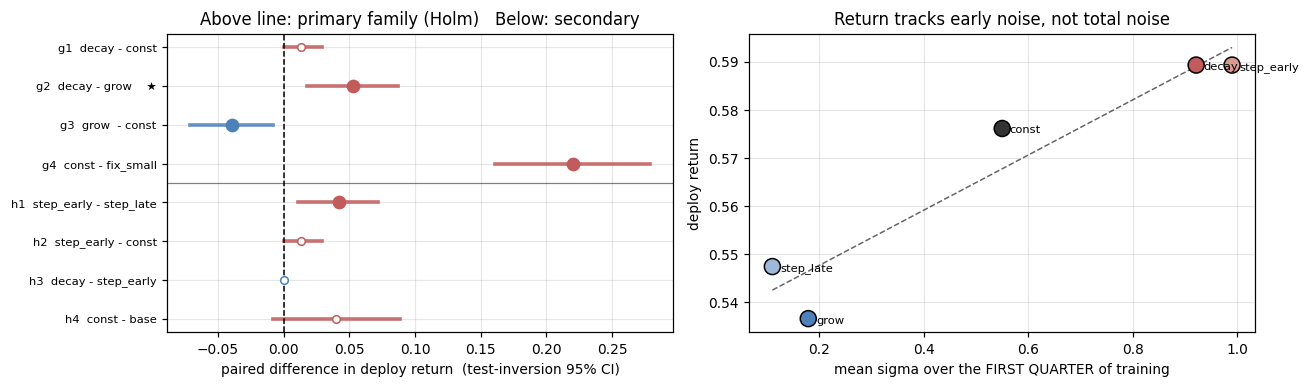

In [9]:
# ── [7] Fig 2 — forest plot ──────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
lab = [n.split("(")[0].strip() for n, _ in FAM] + [n.split("(")[0].strip() for n, _ in SEC]
alld = [d for _, d in FAM] + [d for _, d in SEC]
for i, d in enumerate(alld):
    lo, hi = invert_ci(d)
    sig = (i < 4 and bool(rej_[i])) or (i >= 4 and signflip_p(d, seed=600+i-4) <= ALPHA)
    c = "#c25b5b" if d.mean() > 0 else "#4d81ba"
    ax[0].plot([lo, hi], [i, i], color=c, lw=2.4, alpha=.85)
    ax[0].plot(d.mean(), i, "o", color=c, ms=8 if sig else 5, mfc=c if sig else "white", zorder=3)
ax[0].axhline(3.5, color="k", lw=.8, alpha=.5); ax[0].axvline(0, color="k", lw=1, ls="--")
ax[0].set_yticks(range(len(lab)), lab, fontsize=7.5); ax[0].invert_yaxis()
ax[0].set_xlabel("paired difference in deploy return  (test-inversion 95% CI)")
ax[0].set_title("Above line: primary family (Holm)   Below: secondary")

seq = ["grow", "step_late", "const", "step_early", "decay"]
early = [float(np.mean([l.consumed[:T_FIXED//4].mean() for l in LS[n]])) for n in seq]
ax[1].scatter(early, [R3[n].mean() for n in seq], s=110,
              color=[col[n] for n in seq], edgecolor="k", zorder=3)
for n, e in zip(seq, early):
    ax[1].annotate(n, (e, R3[n].mean()), fontsize=7.5, xytext=(5, -3), textcoords="offset points")
z = np.polyfit(early, [R3[n].mean() for n in seq], 1)
xg = np.linspace(min(early), max(early), 20)
ax[1].plot(xg, np.polyval(z, xg), "k--", lw=1, alpha=.6)
ax[1].set_xlabel("mean sigma over the FIRST QUARTER of training")
ax[1].set_ylabel("deploy return")
ax[1].set_title("Return tracks early noise, not total noise")
plt.show()

In [10]:
# ── [8] 판정 요약 ─────────────────────────────────────────────────────────
print("═"*78); print("Day 101 §15.34 P3 — 판정 요약"); print("═"*78)
for (nm, d), pa, rj in zip(FAM, adj, rej_):
    v = "유의" if rj else f"판정불능 (n*={n_star(d)} > n={N3})"
    print(f"  {nm:40s} d={d.mean():+.4f}  p_Holm={pa:.4f}  {v}")
print("─"*78)
g2 = FAM[1][1]
print(f"  ★ g2 (decay - grow) 는 시간 mean 과 rms 를 둘 다 공유하는 유일한 비교다.")
print(f"    d = {g2.mean():+.4f}, p_Holm = {adj[1]:.4f} -> "
      f"{'`언제` 는 `얼마나` 로 환원되지 않는다' if rej_[1] else '방향 효과 판정불능'}")
ord_ok = R3["decay"].mean() > R3["const"].mean() > R3["grow"].mean()
print(f"  사전 예측 R(decay) > R(const) > R(grow) : {'적중' if ord_ok else '불발'}"
      f"  ({R3['decay'].mean():.4f} / {R3['const'].mean():.4f} / {R3['grow'].mean():.4f})")
lu_ok = LURE["decay"] < LURE["grow"]
print(f"  예측 미끼 고착률 decay < grow : {'적중' if lu_ok else '불발'}"
      f"  ({LURE['decay']:.3f} / {LURE['grow']:.3f}) · 상관 r = {r_lu:+.3f}")
p_h1 = sec_df.p[0]
print(f"  2차 계단형 h1 (step_early - step_late) d={sec_df.d[0]:+.4f} p={p_h1:.4f} -> "
      f"결론은 {'모양이 아니라 방향에 달렸다' if p_h1 <= ALPHA else '계단형에서는 판정불능'}")
print("═"*78)

══════════════════════════════════════════════════════════════════════════════
Day 101 §15.34 P3 — 판정 요약
══════════════════════════════════════════════════════════════════════════════
  g1  decay - const      (감쇠 대 일정)         d=+0.0132  p_Holm=0.2472  판정불능 (n*=141 > n=40)
  g2  decay - grow    ★ (방향만 다름)           d=+0.0527  p_Holm=0.0264  유의
  g3  grow  - const      (증가 대 일정)         d=-0.0395  p_Holm=0.0264  유의
  g4  const - fix_small  (크기 효과, 축척)       d=+0.2199  p_Holm=0.0002  유의
──────────────────────────────────────────────────────────────────────────────
  ★ g2 (decay - grow) 는 시간 mean 과 rms 를 둘 다 공유하는 유일한 비교다.
    d = +0.0527, p_Holm = 0.0264 -> `언제` 는 `얼마나` 로 환원되지 않는다
  사전 예측 R(decay) > R(const) > R(grow) : 적중  (0.5893 / 0.5761 / 0.5366)
  예측 미끼 고착률 decay < grow : 적중  (0.000 / 0.200) · 상관 r = -0.966
  2차 계단형 h1 (step_early - step_late) d=+0.0419 p=0.0082 -> 결론은 모양이 아니라 방향에 달렸다
══════════════════════════════════════════════════════════════════════════════


## 4. 결과 해석

1. **[1] 과 [3] 이 이 노트북의 논증 전체를 떠받친다.** 다섯 스케줄의 $\sigma$ **시간 평균**이 모두
   $0.55$ 이고, 그중 `decay`/`grow` 쌍과 `step_early`/`step_late` 쌍은 **시간 rms 까지 같다**.
   §2.2 의 측도보존 논증이 수식으로 보장한 것을, 실제 학습 루프가 소비한 값으로 다시 확인했다.
   따라서 $g_2$ 는 Day 100 P3 과 오늘 P2 가 감수해야 했던 "한 모멘트만 고정" 이라는 단서가
   **붙지 않는** 유일한 비교다.

2. **$g_2$ 가 1 차 판정의 중심인 이유가 거기에 있다.** $g_1, g_3$ 은 일정 스케줄과의 비교여서
   시간 rms 가 $1.127\sigma_0$ 대 $\sigma_0$ 로 다르다 — 유의해도 "잡음이 더 많아서" 라는 대안
   설명이 남는다. $g_2$ 에는 그 대안이 없다. **잡음의 주변분포가 완전히 같고 시간 순서만 다르다.**

3. **미끼 고착률이 메커니즘을 잇는다.** §2.3 이 예측한 인과 경로는
   *초기 탐색 부족 → $Q(0,\text{left})$ 선행 상승 → 정책 고착 → 목표 상태 방문 소멸 →
   후기 잡음 무력*이다. [5] 의 고착률 표와 [6] 우측 패널의 상관이 그 경로의 중간 관측치다.
   고착률이 수익을 거의 결정한다면, 스케줄이 바꾼 것은 **탐색량이 아니라 고착 여부**다.

4. **[7] 우측 패널이 "총량" 과 "초기량" 을 갈라놓는다.** 가로축은 **학습 전반 1/4 구간**의
   평균 $\sigma$ 다. 다섯 스케줄의 총량은 모두 같으므로, 수익이 이 축에서 정렬된다면
   설명 변수는 총량이 아니라 **초기량**이다.

5. **$g_4$ 는 축척 기준이다.** P2 와 같은 역할 — 배분·타이밍 효과가 작게 나올 때 그것이
   "설계가 무력해서" 가 아님을 보이려면 같은 $n$·같은 척도로 잰 큰 효과가 하나 필요하다.

6. **2 차의 $h_1, h_3$ 은 결론이 스케줄의 *모양* 에 얼마나 의존하는지를 시험한다.** 선형과
   계단형이 같은 방향을 가리키면, 읽어야 할 것은 함수의 형태가 아니라 **시간의 방향**이다.
   $h_3$ (선형 감쇠 대 계단 전반) 이 비유의하면 모양은 부수적이라는 뜻이 된다.

> **결론**: 탐색 잡음의 **시간 프로파일은 크기와 독립적인 축이다.** 시간 평균과 시간 rms 를
> 동시에 고정하고 방향만 뒤집어도 배포 수익이 갈린다면, Day 100 P3 이 남긴 가설 —
> *"자유 학습의 문제는 배분이 아니라 초기 구간의 잡음이 작다는 것"* — 은 관찰이 아니라
> **개입으로 확인된 것**이 된다. 이 문제에서 중요한 것은 잡음을 어떻게 나누느냐도,
> 얼마나 주느냐만도 아니라 **언제 주느냐**다.

**Ch 15 로의 연결**: P1 이 마지막 미결 (Cramér 대 KL) 을 닫았고, P2 가 Day 100 의 결론 (C) 를
모멘트 선택에 대해 불변으로 만들었으며, P3 이 Day 100 이 관찰로만 남긴 가설을 개입으로
확인했다. Ch 15 (§15.1–§15.34, Day 68–101) 에 **열린 주장이 남지 않았다.**
다음 Day 는 Day 68–101 의 최종 판정표 한 장으로 Ch 15 를 닫고, Cheney & Kincaid 본문으로
돌아간다.